# Zynema

## Download Dataset

In [1]:
import gdown
import os

file_id = "1KTB_JuCZliV82zg78esxhm3ebt6kbgNx"
output_file = "NetflixOriginals.csv"

if not os.path.exists(output_file):
    print("Downloading from Google Drive...")
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, output_file, quiet=False)
else:
    print("Dataset already exists, skipping...")

Downloading...
From: https://drive.google.com/uc?id=1KTB_JuCZliV82zg78esxhm3ebt6kbgNx
To: /content/NetflixOriginals.csv
100%|██████████| 38.1k/38.1k [00:00<00:00, 52.2MB/s]


## Load Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, time, requests
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('NetflixOriginals.csv', encoding='latin1')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (584, 6)


,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian


## EDA

In [3]:
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    object 
 1   Genre       584 non-null    object 
 2   Premiere    584 non-null    object 
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 27.5+ KB

Missing Values:
Title         0
Genre         0
Premiere      0
Runtime       0
IMDB Score    0
Language      0
dtype: int64


In [4]:
all_genres = []
for g in df['Genre'].dropna():
    genres = [x.strip() for x in g.split(',')]
    all_genres.extend(genres)

unique_genres = sorted(set(all_genres))
print(f'Total unique genres: {len(unique_genres)}')

Total unique genres: 115


In [5]:
unique_genres

['Action',
 'Action comedy',
 'Action thriller',
 'Action-adventure',
 'Action-thriller',
 'Action/Comedy',
 'Action/Science fiction',
 'Adventure',
 'Adventure-romance',
 'Adventure/Comedy',
 'Aftershow / Interview',
 'Animated musical comedy',
 'Animation',
 'Animation / Comedy',
 'Animation / Musicial',
 'Animation / Science Fiction',
 'Animation / Short',
 'Animation/Christmas/Comedy/Adventure',
 'Animation/Comedy/Adventure',
 'Animation/Musical/Adventure',
 'Animation/Superhero',
 'Anime / Short',
 'Anime/Fantasy',
 'Anime/Science fiction',
 'Anthology/Dark comedy',
 'Biographical/Comedy',
 'Biopic',
 'Black comedy',
 'Christian musical',
 'Christmas comedy',
 'Christmas musical',
 'Christmas/Fantasy/Adventure/Comedy',
 'Comedy',
 'Comedy / Musical',
 'Comedy horror',
 'Comedy mystery',
 'Comedy-drama',
 'Comedy/Fantasy/Family',
 'Comedy/Horror',
 'Coming-of-age comedy-drama',
 'Concert Film',
 'Crime drama',
 'Crime thriller',
 'Dance comedy',
 'Dark comedy',
 'Documentary',
 'Dr

## Data Cleaning

In [6]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip()

# Standardize text to lowercase
df_clean['Genre'] = df_clean['Genre'].str.lower().str.strip()
df_clean['Title'] = df_clean['Title'].str.lower().str.strip()
df_clean['Language'] = df_clean['Language'].str.lower().str.strip()

# Replace slashes (/) and hyphens (-) with commas for consistent genre formatting
df_clean['Genre'] = df_clean['Genre'].str.replace('/', ', ', regex=False)
df_clean['Genre'] = df_clean['Genre'].str.replace('-', ', ', regex=False)

# Remove extra spaces and normalize comma spacing
df_clean['Genre'] = df_clean['Genre'].str.replace(r'\s+,', ',', regex=True)
df_clean['Genre'] = df_clean['Genre'].str.replace(r',\s+', ', ', regex=True)
df_clean['Genre'] = df_clean['Genre'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Remove extra spaces in title and language columns
df_clean['Title'] = df_clean['Title'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_clean['Language'] = df_clean['Language'].str.replace(r'\s+', ' ', regex=True).str.strip()

display(df_clean[['Title', 'Genre', 'Language']].head(5))

,Title,Genre,Language
0,enter the anime,documentary,english/japanese
1,dark forces,thriller,spanish
2,the app,"science fiction, drama",italian
3,the open house,horror thriller,english
4,kaali khuhi,mystery,hindi


## Genre Mapping

In [7]:
def map_to_parent_genre(genre_str):
    if pd.isna(genre_str):
        return []
    genre_lower = genre_str.lower()
    parent_mapping = {
        'action':      ['action', 'superhero', 'heist', 'spy', 'martial'],
        'adventure':   ['adventure', 'exploration'],
        'animation':   ['animation', 'animated', 'anime', 'stop motion', 'cgi'],
        'comedy':      ['comedy', 'dark comedy', 'black comedy', 'satire', 'slapstick', 'parody'],
        'documentary': ['documentary', 'making of', 'mockumentary', 'concert film'],
        'drama':       ['drama', 'biopic', 'historical', 'sports', 'coming of age', 'biographical', 'crime drama'],
        'family':      ['family', 'christmas', 'holiday', 'kids'],
        'fantasy':     ['fantasy', 'magical', 'mythology'],
        'horror':      ['horror', 'zombie', 'supernatural horror', 'psychological horror'],
        'musical':     ['musical', 'concert', 'dance'],
        'mystery':     ['mystery', 'detective'],
        'romance':     ['romance', 'romantic', 'love'],
        'scifi':       ['science fiction', 'sci fi'],
        'thriller':    ['thriller'],
        'war':         ['war', 'military'],
        'western':     ['western'],
    }
    matched = []
    for parent, keywords in parent_mapping.items():
        for kw in keywords:
            if kw in genre_lower:
                matched.append(parent)
                break
    return list(set(matched)) if matched else ['other']

df_clean['parent_genre'] = df_clean['Genre'].apply(map_to_parent_genre)
df_clean['parent_genre_str'] = df_clean['parent_genre'].apply(lambda x: ', '.join(x))

df_clean[['Title', 'Genre', 'parent_genre_str']].head(3)

,Title,Genre,parent_genre_str
0,enter the anime,documentary,documentary
1,dark forces,thriller,thriller
2,the app,"science fiction, drama","scifi, drama"


## Feature Engineering

In [8]:
def create_metadata(row):
    title = str(row['Title']).strip() if pd.notna(row['Title']) else 'unknown'
    genre = str(row['parent_genre_str']).strip() if pd.notna(row['parent_genre_str']) else 'unknown'
    language = str(row['Language']).strip() if pd.notna(row['Language']) else 'unknown'
    return f"movie title is {title}. genre is {genre}. language is {language}."

df_clean['metadata'] = df_clean.apply(create_metadata, axis=1)

df_clean['year'] = df_clean['Premiere'].str.extract(r'(\d{4})').astype(float)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_clean['runtime_normalized'] = scaler.fit_transform(df_clean[['Runtime']])

df_clean['primary_language'] = df_clean['Language'].str.split('/').str[0].str.strip()
df_clean['all_languages'] = df_clean['Language'].str.split('/').apply(
    lambda x: [l.strip() for l in x] if isinstance(x, list) else []
)

df_clean[['Title', 'year', 'Runtime', 'runtime_normalized', 'primary_language']].head(3)

,Title,year,Runtime,runtime_normalized,primary_language
0,enter the anime,2019.0,58,0.263415,english
1,dark forces,2020.0,81,0.375610,spanish
2,the app,2019.0,79,0.365854,italian


## Visualization

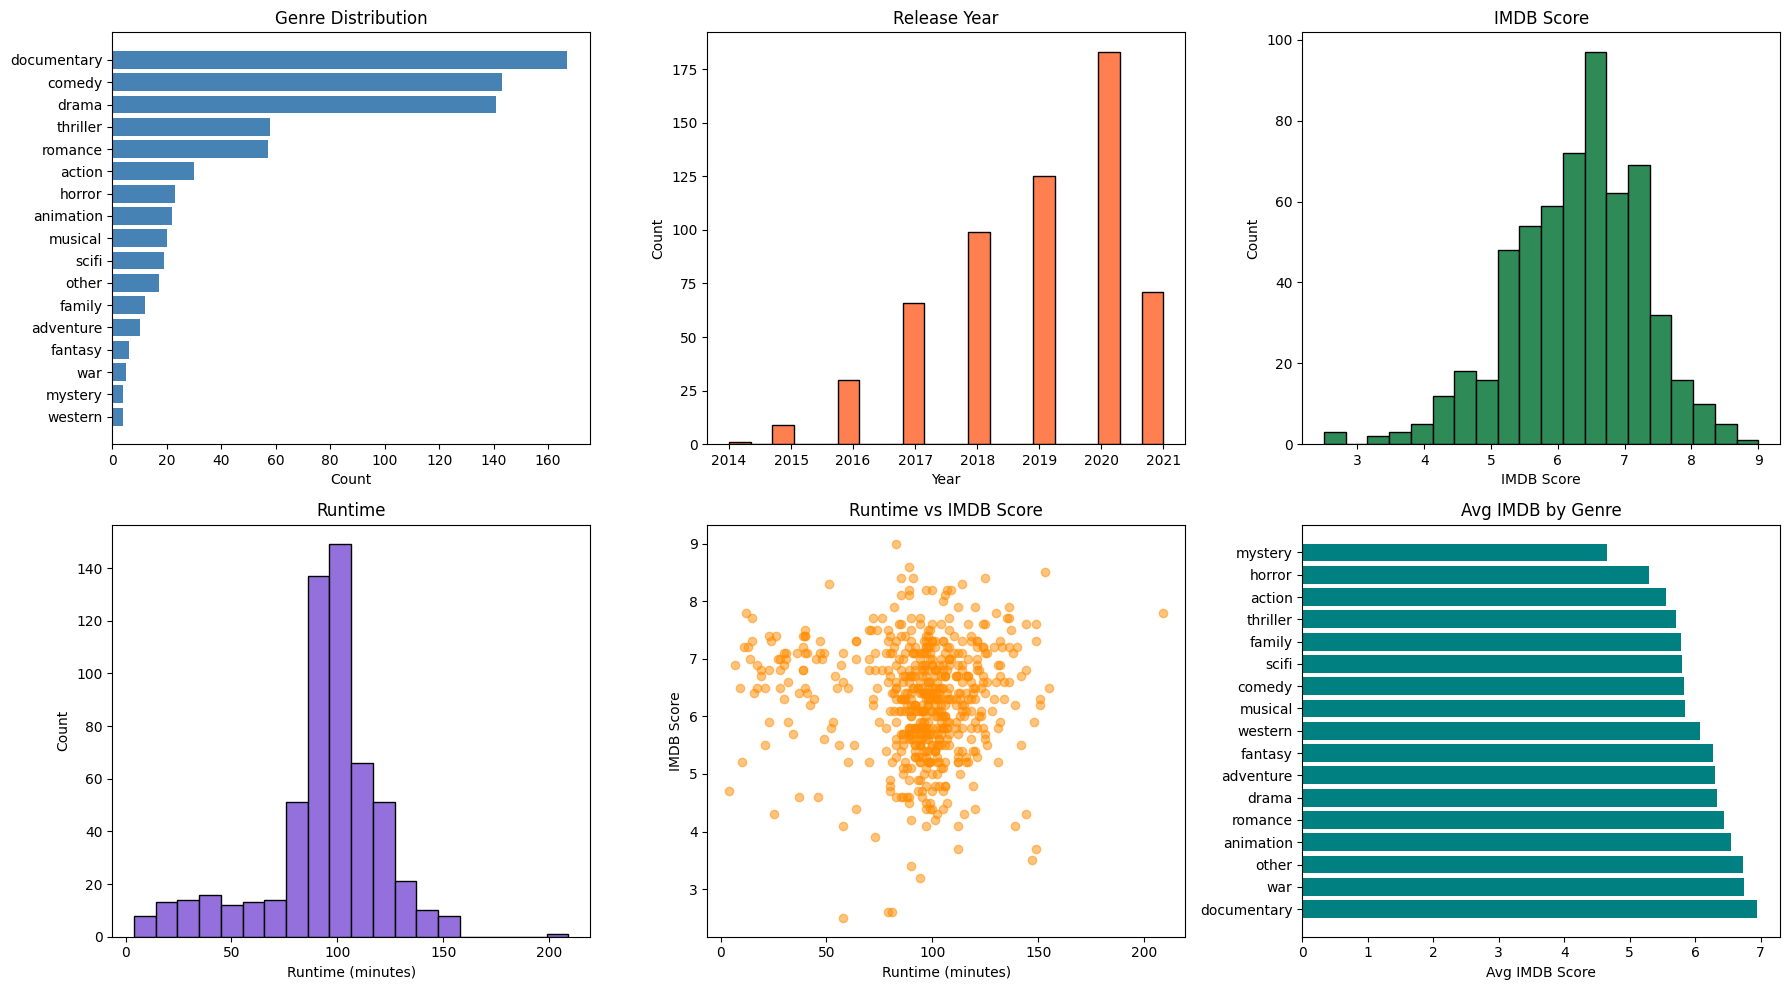

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

genre_counts = df_clean['parent_genre_str'].str.split(', ').explode().value_counts()
axes[0, 0].barh(genre_counts.index, genre_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Genre Distribution')
axes[0, 0].invert_yaxis()

axes[0, 1].hist(df_clean['year'].dropna(), bins=20, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Release Year')

axes[0, 2].hist(df_clean['IMDB Score'].dropna(), bins=20, color='seagreen', edgecolor='black')
axes[0, 2].set_xlabel('IMDB Score')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('IMDB Score')

axes[1, 0].hist(df_clean['Runtime'].dropna(), bins=20, color='mediumpurple', edgecolor='black')
axes[1, 0].set_xlabel('Runtime (minutes)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Runtime')

axes[1, 1].scatter(df_clean['Runtime'], df_clean['IMDB Score'], alpha=0.5, color='darkorange')
axes[1, 1].set_xlabel('Runtime (minutes)')
axes[1, 1].set_ylabel('IMDB Score')
axes[1, 1].set_title('Runtime vs IMDB Score')

genre_imdb = df_clean.groupby(df_clean['parent_genre_str'].str.split(', ').str[0])['IMDB Score'].mean().sort_values(ascending=True)
axes[1, 2].barh(genre_imdb.index, genre_imdb.values, color='teal')
axes[1, 2].set_xlabel('Avg IMDB Score')
axes[1, 2].set_title('Avg IMDB by Genre')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

### Correlation Heatmap

Let's create a heatmap to visualize the correlation between numerical features. This can help identify which features are strongly related to each other or to the target variable (if we were building a model).

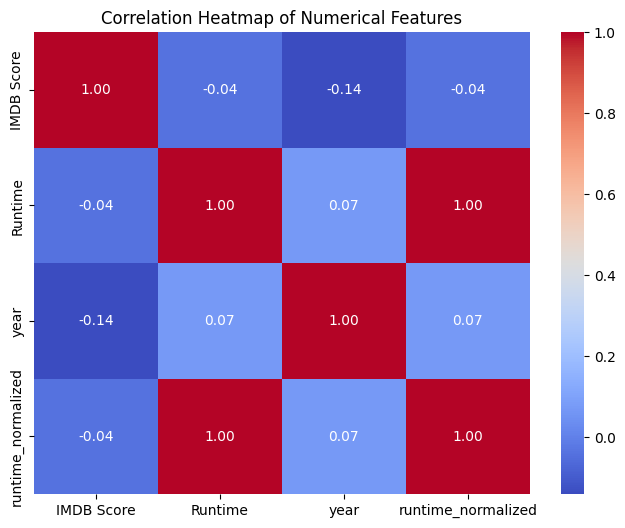

In [10]:
numerical_cols = ['IMDB Score', 'Runtime', 'year', 'runtime_normalized']
correlation_matrix = df_clean[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Merge Poster (Optional)

In [11]:
try:
    from google.colab import files
    uploaded_old = files.upload()
    df_old = pd.read_csv(list(uploaded_old.keys())[0])
    if 'poster' in df_old.columns:
        old_posters = dict(zip(df_old['Title'].str.lower(), df_old['poster']))
        merged, reused = [], 0
        for title in df_clean['Title']:
            if title in old_posters and pd.notna(old_posters.get(title)):
                merged.append(old_posters[title])
                reused += 1
            else:
                merged.append(None)
        df_clean['poster'] = merged
        print(f"Reused: {reused} | Need fetch: {len(df_clean) - reused}")
    else:
        df_clean['poster'] = None
except:
    df_clean['poster'] = None
    print("No old dataset, will fetch all posters")

Saving netflix_cleaned2.csv to netflix_cleaned2.csv
Reused: 529 | Need fetch: 55


## Fetch Poster

In [12]:
def get_poster_omdb(title, retries=3, delay=1.1):
    url = 'https://www.omdbapi.com/'
    for _ in range(retries):
        try:
            params = {'apikey': API_KEY, 't': title}
            r = requests.get(url, params=params, timeout=10)
            if r.status_code == 200:
                data = r.json()
                if data.get('Response') == 'True':
                    poster = data.get('Poster')
                    if poster and poster != 'N/A':
                        return poster
                time.sleep(delay * 2)
            else:
                time.sleep(delay * 2)
        except:
            time.sleep(delay * 2)
    return None

to_fetch = df_clean[df_clean['poster'].isna()].copy()
print(f"Total: {len(df_clean)} | Already have: {len(df_clean) - len(to_fetch)} | Need fetch: {len(to_fetch)}")

success = 0
failed = 0

for i, (_, row) in enumerate(to_fetch.iterrows(), 1):
    poster = get_poster_omdb(row['Title'])
    df_clean.loc[row.name, 'poster'] = poster
    success += 1 if poster else 0
    failed += 1 if not poster else 0
    if i % 10 == 0 or i == len(to_fetch):
        print(f"Progress: {i}/{len(to_fetch)} | Success: {success} | Failed: {failed}")
    time.sleep(1.1)

print(f"Done. Success: {success} | Failed: {failed}")

Total: 584 | Already have: 529 | Need fetch: 55
Progress: 10/55 | Success: 0 | Failed: 10
Progress: 20/55 | Success: 0 | Failed: 20
Progress: 30/55 | Success: 0 | Failed: 30
Progress: 40/55 | Success: 0 | Failed: 40
Progress: 50/55 | Success: 0 | Failed: 50
Progress: 55/55 | Success: 0 | Failed: 55
Done. Success: 0 | Failed: 55


### OMDb API: Available Movie Details

The OMDb API provides a comprehensive set of information for movies:

*   **Title**: The title of the movie.
*   **Year**: The release year.
*   **Rated**: The MPAA rating (e.g., PG, R).
*   **Released**: The full release date.
*   **Runtime**: The duration of the movie.
*   **Genre**: The genre(s) of the movie.
*   **Director**: The director(s) of the movie.
*   **Writer**: The writer(s) of the movie.
*   **Actors**: The main actors in the movie.
*   **Plot**: A brief summary of the movie's plot.
*   **Language**: The language(s) of the movie.
*   **Country**: The country (or countries) of origin.
*   **Awards**: Information about awards won.
*   **Poster**: The URL to the movie poster.
*   **Ratings**: External ratings (e.g., IMDb, Rotten Tomatoes, Metacritic).
*   **Metascore**: Metacritic score.
*   **imdbRating**: IMDb rating.
*   **imdbVotes**: Number of IMDb votes.
*   **imdbID**: The IMDb identifier.
*   **Type**: Type of content (e.g., movie, series, episode).
*   **DVD**: DVD release date.
*   **BoxOffice**: Box office revenue.
*   **Production**: Production company.
*   **Website**: Official website URL.
*   **Response**: Indicates if the API request was successful.

### Set up OMDb API Key

To use the OMDb API, need an API key that can obtain one by registering at [https://www.omdbapi.com/](https://www.omdbapi.com/).

Once have API key, store it securely in Colab's secrets manager. Click on the "🔑" icon in the left panel, add a new secret, and name it `OMDB_API_KEY`. Then, the following cell will retrieve it.

In [14]:
from google.colab import userdata

API_KEY = userdata.get('OMDB_API')

if API_KEY is None:
    raise ValueError("OMDB_API_KEY not found in secrets. Please set it up.")

print("OMDb API Key loaded successfully.")

OMDb API Key loaded successfully.


In [15]:
def get_movie_details_omdb(title, retries=3, delay=1.1):
    url = 'https://www.omdbapi.com/'
    for _ in range(retries):
        try:
            params = {'apikey': API_KEY, 't': title}
            r = requests.get(url, params=params, timeout=10)
            if r.status_code == 200:
                data = r.json()
                if data.get('Response') == 'True':
                    return {
                        'Director': data.get('Director', 'N/A'),
                        'Actors': data.get('Actors', 'N/A'),
                        'Plot': data.get('Plot', 'N/A'),
                        'OMDB_Genre': data.get('Genre', 'N/A'),
                        'Released': data.get('Released', 'N/A'),
                        'OMDB_Runtime': data.get('Runtime', 'N/A'),
                        'OMDB_IMDB_Score': data.get('imdbRating', 'N/A'),
                        'poster': data.get('Poster', 'N/A'), # Changed to lowercase 'poster' for consistency
                        'Rated': data.get('Rated', 'N/A'),
                        'Writer': data.get('Writer', 'N/A'),
                        'Awards': data.get('Awards', 'N/A'),
                        'BoxOffice': data.get('BoxOffice', 'N/A'),
                        'Production': data.get('Production', 'N/A'),
                        'Country': data.get('Country', 'N/A')
                    }
                time.sleep(delay * 2)
            else:
                time.sleep(delay * 2)
        except:
            time.sleep(delay * 2)
    return None

# Initialize new columns with None if they don't exist to prevents overwriting if they were partially filled or already exist
for col in ['Director', 'Actors', 'Plot', 'OMDB_Genre', 'Released', 'OMDB_Runtime', 'OMDB_IMDB_Score', 'Rated', 'Writer', 'Awards', 'BoxOffice', 'Production', 'Country', 'poster']:
    if col not in df_clean.columns:
        df_clean[col] = None

# Filter for movies where we are missing 'Director' (or any of the new OMDB fields)
to_fetch_omdb = df_clean[df_clean['Director'].isna()].copy()
print(f"Total movies: {len(df_clean)} | Movies with OMDB details: {len(df_clean) - len(to_fetch_omdb)} | Need to fetch OMDB details: {len(to_fetch_omdb)}")

success_omdb = 0
failed_omdb = 0

for i, (_, row) in enumerate(to_fetch_omdb.iterrows(), 1):
    movie_details = get_movie_details_omdb(row['Title'])
    if movie_details:
        for key, value in movie_details.items():
            df_clean.loc[row.name, key] = value if value != 'N/A' else None
        success_omdb += 1
    else:
        failed_omdb += 1

    if i % 10 == 0 or i == len(to_fetch_omdb):
        print(f"Progress: {i}/{len(to_fetch_omdb)} | Success: {success_omdb} | Failed: {failed_omdb}")
    time.sleep(1.1)

print(f"Done. Success: {success_omdb} | Failed: {failed_omdb}")

# Display the first few rows with new columns to verify
display(df_clean[['Title', 'Director', 'Actors', 'OMDB_Genre', 'OMDB_IMDB_Score', 'Rated', 'Writer', 'Awards', 'BoxOffice', 'Production', 'Country', 'poster']].head())

Total movies: 584 | Movies with OMDB details: 0 | Need to fetch OMDB details: 584
Progress: 10/584 | Success: 10 | Failed: 0
Progress: 20/584 | Success: 19 | Failed: 1
Progress: 30/584 | Success: 28 | Failed: 2
Progress: 40/584 | Success: 37 | Failed: 3
Progress: 50/584 | Success: 46 | Failed: 4
Progress: 60/584 | Success: 56 | Failed: 4
Progress: 70/584 | Success: 65 | Failed: 5
Progress: 80/584 | Success: 75 | Failed: 5
Progress: 90/584 | Success: 85 | Failed: 5
Progress: 100/584 | Success: 95 | Failed: 5
Progress: 110/584 | Success: 105 | Failed: 5
Progress: 120/584 | Success: 114 | Failed: 6
Progress: 130/584 | Success: 124 | Failed: 6
Progress: 140/584 | Success: 133 | Failed: 7
Progress: 150/584 | Success: 143 | Failed: 7
Progress: 160/584 | Success: 153 | Failed: 7
Progress: 170/584 | Success: 162 | Failed: 8
Progress: 180/584 | Success: 172 | Failed: 8
Progress: 190/584 | Success: 182 | Failed: 8
Progress: 200/584 | Success: 192 | Failed: 8
Progress: 210/584 | Success: 202 | Fa

,Title,Director,Actors,OMDB_Genre,OMDB_IMDB_Score,Rated,Writer,Awards,BoxOffice,Production,Country,poster
0,enter the anime,Alex Burunova,"Shinji Aramaki, Kôzô Morishita, Tania Nolan",Documentary,2.6,None,"Julia Yorks, Meggy Garol",None,None,None,"United States, Japan",https://m.media-amazon.com/images/M/MV5BNzljM2...
1,dark forces,Bernardo Arellano,"Tenoch Huerta, Eréndira Ibarra, Dale Carley","Action, Horror, Mystery",2.8,None,Bernardo Arellano,None,None,None,Mexico,https://m.media-amazon.com/images/M/MV5BOTIxMW...
2,the app,Elisa Fuksas,"Salvatore Costa, Vincenzo Crea, Jessica Cressy","Drama, Sci-Fi, Thriller",2.8,None,"Elisa Fuksas, Lucio Pellegrini",None,None,None,Italy,https://m.media-amazon.com/images/M/MV5BNzgzZG...
3,the open house,"Matt Angel, Suzanne Coote","Dylan Minnette, Piercey Dalton, Patricia Bethune","Horror, Thriller",3.3,TV-MA,"Matt Angel, Suzanne Coote",None,None,None,"Canada, United States",https://m.media-amazon.com/images/M/MV5BMTU0Mj...
4,kaali khuhi,Terrie Samundra,"Shabana Azmi, Sanjeeda Sheikh, Satyadeep Misra","Drama, Horror, Mystery",3.7,TV-14,"Rupinder Inderjit, David Walter Lech, Terrie S...",1 win,None,None,India,https://m.media-amazon.com/images/M/MV5BZjRhNG...


In [16]:
display(df_clean[['Title', 'Director', 'Actors', 'OMDB_Genre', 'OMDB_IMDB_Score', 'Rated', 'Writer', 'Awards', 'BoxOffice', 'Production', 'Country', 'poster']].head(10)) # Changed to lowercase 'poster'

,Title,Director,Actors,OMDB_Genre,OMDB_IMDB_Score,Rated,Writer,Awards,BoxOffice,Production,Country,poster
0,enter the anime,Alex Burunova,"Shinji Aramaki, Kôzô Morishita, Tania Nolan",Documentary,2.6,None,"Julia Yorks, Meggy Garol",None,None,None,"United States, Japan",https://m.media-amazon.com/images/M/MV5BNzljM2...
1,dark forces,Bernardo Arellano,"Tenoch Huerta, Eréndira Ibarra, Dale Carley","Action, Horror, Mystery",2.8,None,Bernardo Arellano,None,None,None,Mexico,https://m.media-amazon.com/images/M/MV5BOTIxMW...
2,the app,Elisa Fuksas,"Salvatore Costa, Vincenzo Crea, Jessica Cressy","Drama, Sci-Fi, Thriller",2.8,None,"Elisa Fuksas, Lucio Pellegrini",None,None,None,Italy,https://m.media-amazon.com/images/M/MV5BNzgzZG...
3,the open house,"Matt Angel, Suzanne Coote","Dylan Minnette, Piercey Dalton, Patricia Bethune","Horror, Thriller",3.3,TV-MA,"Matt Angel, Suzanne Coote",None,None,None,"Canada, United States",https://m.media-amazon.com/images/M/MV5BMTU0Mj...
4,kaali khuhi,Terrie Samundra,"Shabana Azmi, Sanjeeda Sheikh, Satyadeep Misra","Drama, Horror, Mystery",3.7,TV-14,"Rupinder Inderjit, David Walter Lech, Terrie S...",1 win,None,None,India,https://m.media-amazon.com/images/M/MV5BZjRhNG...
5,drive,Nicolas Winding Refn,"Ryan Gosling, Carey Mulligan, Bryan Cranston","Action, Drama",7.8,R,"Hossein Amini, James Sallis",Nominated for 1 Oscar. 79 wins & 180 nominatio...,"$35,061,555",None,United States,https://m.media-amazon.com/images/M/MV5BYTFmNT...
6,leyla everlasting,Ezel Akay,"Haluk Bilginer, Demet Akbag, Elçin Sangu",Comedy,3.7,TV-MA,"Ezel Akay, Özlem Lale, Ugur Saatci",None,None,None,Turkey,https://m.media-amazon.com/images/M/MV5BMmZkNW...
7,the last days of american crime,Olivier Megaton,"Neels Clasen, Edgar Ramírez, Tony Caprari","Action, Crime, Drama",3.8,TV-MA,"Karl Gajdusek, Rick Remender, Greg Tocchini",None,None,None,United States,https://m.media-amazon.com/images/M/MV5BNjkxZT...
8,paradox,Wilson Yip,"Louis Koo, Yue Wu, Ka-Tung Lam","Action, Adventure, Crime",6.5,None,"Nick Cheuk, Lai-Yin Leung",6 wins & 10 nominations total,None,None,"China, Hong Kong",https://m.media-amazon.com/images/M/MV5BOGM0Mz...
9,sardar ka grandson,Kaashvi Nair,"Aditi Rao Hydari, John Abraham, Rakul Preet Singh","Comedy, Drama, Romance",4.3,TV-14,"Anuja Chauhan, Amitosh Nagpal, Kaashvi Nair",1 win & 5 nominations,None,None,India,https://m.media-amazon.com/images/M/MV5BZGYxMj...


In [17]:
display(df_clean['Actors'].unique())

array(['Shinji Aramaki, Kôzô Morishita, Tania Nolan',
       'Tenoch Huerta, Eréndira Ibarra, Dale Carley',
       'Salvatore Costa, Vincenzo Crea, Jessica Cressy',
       'Dylan Minnette, Piercey Dalton, Patricia Bethune',
       'Shabana Azmi, Sanjeeda Sheikh, Satyadeep Misra',
       'Ryan Gosling, Carey Mulligan, Bryan Cranston',
       'Haluk Bilginer, Demet Akbag, Elçin Sangu',
       'Neels Clasen, Edgar Ramírez, Tony Caprari',
       'Louis Koo, Yue Wu, Ka-Tung Lam',
       'Aditi Rao Hydari, John Abraham, Rakul Preet Singh',
       'Ma Anand Sheela, Shoma Chaudhury, Anurag Chauhan',
       'Halle Berry, Evie Thompson, Abigail Breslin',
       'Amanda Peet, Brian Van Holt, Jonathan Abrahams',
       'Hairul Azreen, Janna Nick, Amerul Affendi',
       'Chris Pratt, Rebecca Ferguson, Kali Reis', None,
       'Samuel Bottomley, Deborah Wastell, Amy Doyle',
       'Anne Hathaway, Ben Affleck, Rosie Perez',
       'Mamoru Miyano, Brad Swaile, Vincent Tong',
       'Chelsea Handler, 

In [18]:
all_actors = df_clean['Actors'].dropna().apply(lambda x: [actor.strip().lower() for actor in x.split(',')]).explode()
unique_actors_count = all_actors.nunique()
print(f"Total unique actors: {unique_actors_count}")

Total unique actors: 1454


In [19]:
# Display most frequent actors
actor_counts = all_actors.value_counts()
display(actor_counts.head(50)) 

,count
Actors,
adam sandler,6
gary oldman,4
noah centineo,4
vanessa hudgens,4
judah lewis,3
alice krige,3
ben lamb,3
rose mciver,3
darby camp,3


## Validate Poster

In [20]:
def check_poster_url(url):
    if not url:
        return False
    try:
        return requests.head(url, timeout=5).status_code == 200
    except:
        return False

df_clean['poster_valid'] = df_clean['poster'].apply(check_poster_url)
before = len(df_clean)
df_clean = df_clean[df_clean['poster_valid']].drop(columns=['poster_valid']).reset_index(drop=True)

print(f"Valid: {len(df_clean)} | Removed: {before - len(df_clean)}")

Valid: 531 | Removed: 53


## Export

In [23]:
import json
from google.colab import files

# 1. Re-run genre mapping
df_clean['parent_genre'] = df_clean['Genre'].apply(map_to_parent_genre)
df_clean['parent_genre_str'] = df_clean['parent_genre'].apply(lambda x: ', '.join(x))

# Add main_parent_genre column by taking the first genre
df_clean['main_parent_genre'] = df_clean['parent_genre'].apply(lambda x: x[0] if x else None)

# 2. Feature re-engineering
df_clean['metadata'] = df_clean.apply(create_metadata, axis=1)
df_clean['year_premiere'] = df_clean['Premiere'].str.extract(r'(\d{4})').astype(float)
df_clean['runtime_normalized'] = scaler.transform(df_clean[['Runtime']])
df_clean['primary_language'] = df_clean['Language'].str.split('/').str[0].str.strip()

# 3. Use posters from the previously uploaded file (without API fetching)
if 'df_old' in globals() and 'poster' in df_old.columns:
    old_posters = dict(zip(df_old['Title'].str.lower(), df_old['poster']))
    df_clean['poster'] = df_clean['Title'].map(old_posters)
else:
    print('Warning: Poster data was not found in the df_old variable.')

# 4. Keep only rows with available posters to prevent application errors
df_final = df_clean[df_clean['poster'].notna()].reset_index(drop=True)

# Add capitalized primary language column
df_final['primary_language_capitalized'] = df_final['primary_language'].str.capitalize()

# 5. Prepare export - only include required columns
# (14 columns: 3 predictors + main genre + supporting features)
df_export = df_final[['Title', 'Genre', 'parent_genre_str', 'main_parent_genre', 'metadata',
                       'poster', 'year_premiere', 'IMDB Score', 'Runtime',
                       'runtime_normalized', 'primary_language_capitalized', 'Premiere',
                       'Director', 'Plot']].copy()

df_export.to_csv('netflix_cleaned_dataset.csv.csv', index=False)

# 6. Generate categories.json
# (still based on all possible parent genres)
all_genre_names = ['action', 'adventure', 'animation', 'comedy', 'documentary', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller', 'war', 'western', 'other']
categories_json = [{'id': i+1, 'name': cat} for i, cat in enumerate(sorted(all_genre_names))]
with open('categories.json', 'w') as f:
    json.dump(categories_json, f, indent=2)

print(f'Completed! Successfully processed {len(df_export)} movies using existing poster data.')
files.download('netflix_cleaned_dataset.csv.csv')
files.download('categories.json')

Selesai! Berhasil memproses 529 film menggunakan data poster yang ada.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>